# Deep Gaussian Process (DGP) dari Nol (From Scratch)

Welcome! Notebook ini dirancang sebagai panduan langkah-demi-langkah (*walkthrough*) untuk memahami dan mengimplementasikan **Deep Gaussian Process (DGP)** dari dasar (*from scratch*).

---

## 🎯 Tujuan Pembelajaran
1. **Memahami Keterbatasan Single-Layer GP**: Mengapa Gaussian Process standar kesulitan menangani data *non-stationary* (misalnya fungsi dengan frekuensi berubah cepat atau lompatan mendadak).
2. **Konsep Komposisi Layer pada DGP**: Bagaimana fungsi laten dihubungkan secara hierarkis ($y = f^{(L)}(f^{(L-1)}(\dots f^{(1)}(x)))$) untuk melakukan *input space warping*.
3. **Sparse Variational Inference & Inducing Points (SVGP / DSVI)**: Solusi matematika (Titsias, 2009; Hensman et al., 2013; Salimbeni & Deisenroth, 2017) untuk mengestimasi *posterior intractable* pada GP skala besar dan DGP menggunakan $M$ titik induksi (*inducing points*, $M \ll N$) dan *reparameterization trick*.
4. **Implementasi From-Scratch dalam PyTorch**: Membangun Kernel RBF, Sparse Variational GP (SVGP) Layer, dan Deep GP Model menggunakan operasi tensor dasar PyTorch tanpa bantuan library GP tingkat tinggi (seperti GPyTorch atau GPflow).
5. **Visualisasi Space Warping**: Mengamati bagaimana layer tersembunyi (*hidden layer*) mengubah representasi ruang input sehingga fungsi non-stasioner menjadi mudah dipelajari.

## 1. Setup Environment & Library

Kita hanya menggunakan library dasar Python:
- `numpy`: Manipulasi data sintetis dan numerik dasar.
- `matplotlib.pyplot`: Visualisasi fungsi, uncertainty boundary, dan representasi laten.
- `torch` & `torch.nn`: Operasi aljabar linier tensor dan *automatic differentiation* (autograd) untuk mengoptimalkan parameter ELBO.

> **Catatan**: Kita **tidak** menggunakan `gpytorch`, `gpflow`, atau library GP ber-level tinggi lainnya. Semua logika kernel, matriks kovariansi, inferensi variasional, dan ELBO dibuat murni dari persamaan matematikanya.

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time

# Set random seed untuk hasil yang reproducible
torch.manual_seed(42)
np.random.seed(42)

# Set style plot Matplotlib agar tampak profesional
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 100

print(f"PyTorch Version: {torch.__version__}")
print("Environment siap untuk eksplorasi Deep Gaussian Process!")

PyTorch Version: 2.12.0+cpu
Environment siap untuk eksplorasi Deep Gaussian Process!


## 2. Motivasi: Keterbatasan Single-Layer Gaussian Process (Standard GP)

### Mengapa Single GP Kesulitan pada Data Non-Stationary?
Suatu proses Gauss (GP) standar dengan Kernel Radial Basis Function (RBF / Squared Exponential) memiliki asumsi **stasioneritas** (*stationarity*):
$$k_{RBF}(x, x') = \sigma_f^2 \exp\left( -\frac{\|x - x'\|^2}{2\ell^2} \right)$$

Di sini, hyperparameter *lengthscale* $\ell$ bersifat global (konstan di seluruh ruang input $x$).
- Jika $\ell$ terlalu besar, GP akan **over-smooth** pada area yang berubah cepat (frekuensi tinggi / lompatan).
- Jika $\ell$ terlalu kecil, GP akan **over-fit** pada area yang halus dan menghasilkan ketidakpastian (*uncertainty*) yang tidak realistis pada area yang jarang data.

Mari kita buat dataset sintetis yang bersifat *non-stationary* (gabungan sinyal frekuensi rendah dan frekuensi tinggi).

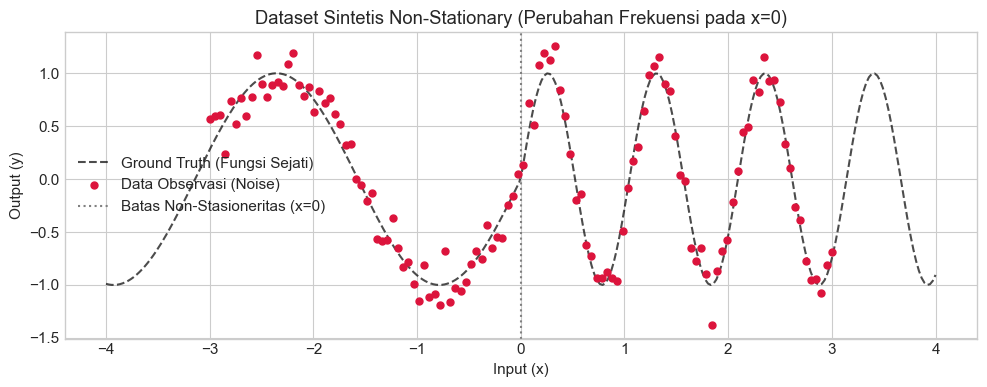

In [ ]:
# Membuat Dataset Sintetis Non-Stationary
# x < 0: Frekuensi rendah sin(2x)
# x >= 0: Frekuensi tinggi sin(6x)
N_train = 120
X_train = torch.linspace(-3, 3, N_train).unsqueeze(1)

# Fungsi sejati (ground truth) tanpa noise
y_true = torch.where(X_train < 0, torch.sin(2 * X_train), torch.sin(6 * X_train))

# Menambahkan Gaussian noise N(0, 0.15^2)
noise_std = 0.15
Y_train = y_true + noise_std * torch.randn_like(X_train)

# Test grid untuk evaluasi dan plot prediksi
X_test = torch.linspace(-4, 4, 300).unsqueeze(1)
Y_test_true = torch.where(X_test < 0, torch.sin(2 * X_test), torch.sin(6 * X_test))

# Visualisasi Data Sintetis
plt.figure(figsize=(10, 4))
plt.plot(X_test.numpy(), Y_test_true.numpy(), 'k--', label='Ground Truth (Fungsi Sejati)', alpha=0.7)
plt.scatter(X_train.numpy(), Y_train.numpy(), c='crimson', s=25, label='Data Observasi (Noise)', zorder=3)
plt.axvline(0, color='gray', linestyle=':', label='Batas Non-Stasioneritas (x=0)')
plt.title("Dataset Sintetis Non-Stationary (Perubahan Frekuensi pada x=0)")
plt.xlabel("Input (x)")
plt.ylabel("Output (y)")
plt.legend()
plt.tight_layout()
plt.show()

### Baseline: Single-Layer Sparse Variational Gaussian Process (SVGP)

Sebelum masuk ke Deep GP, mari kita buat **Single-Layer Sparse Variational GP (SVGP)** (Titsias, 2009; Hensman et al., 2013) terlebih dahulu sebagai pembanding (*baseline*).

Pada SVGP, alih-alih menghitung kovariansi untuk seluruh $N$ data latih (yang berbiaya komputasi $\mathcal{O}(N^3)$), kita menggunakan $M$ buah titik perwakilan yang disebut **Inducing Points $Z$** ($M \ll N$) dengan distribusi variasional $q(u) = \mathcal{N}(m, S)$ pada variabel laten induksi $u = f(Z)$:
1. Matriks Kovariansi Antar Inducing Points: $K_{ZZ} = k(Z, Z) + \sigma_{jitter}^2 I \in \mathbb{R}^{M \times M}$
2. Matriks Kovariansi Input-Inducing: $K_{XZ} = k(X, Z) \in \mathbb{R}^{N \times M}$
3. Matriks Proyeksi: $A = K_{XZ} K_{ZZ}^{-1} \in \mathbb{R}^{N \times M}$
4. Distribusi Kondisional $q(f \mid X) \sim \mathcal{N}(\mu(X), \text{Var}(f(X)))$:
   $$\mu(X) = A m$$
   $$\text{Var}(f(X)) = \text{diag}(K_{XX}) - \text{diag}(A K_{ZX}) + \text{diag}(A S A^T)$$

Mari kita latih Single-Layer SVGP ini pada data non-stasioner di atas.

> **💡 Catatan Konsep Penting: Mengapa ini disebut SVGP?**
> - **VGP Asli (Opper & Archambeau, 2009)**: Variational inference diterapkan langsung pada seluruh $N$ titik data ($f \in \mathbb{R}^N$) tanpa inducing points, sehingga kompleksitasnya tetap $\mathcal{O}(N^3)$.
> - **SVGP (Titsias, 2009; Hensman et al., 2013)**: Memperkenalkan $M$ titik acuan (**Inducing Points $Z$**, di mana $M \ll N$) dan variabel laten $u = f(Z) \sim q(u) = \mathcal{N}(m, S)$. Kompleksitas komputasi turun drastis menjadi $\mathcal{O}(NM^2 + M^3)$ dan mendukung *stochastic mini-batch training*.
> - Rumus proyeksi analitik kondisional $\mu(X) = A m$ dan varians di atas adalah turunan kanonikal dari **SVGP**.

In [ ]:
class SingleLayerSVGP(nn.Module):
    """
    Single-Layer Sparse Variational Gaussian Process (SVGP)
    Berdasarkan formulasi Titsias (2009) & Hensman et al. (2013)
    """
    def __init__(self, input_dim=1, output_dim=1, num_inducing=16, X_init=None):
        super().__init__()
        self.num_inducing = num_inducing
        
        # Hyperparameter Kernel RBF
        self.raw_lengthscale = nn.Parameter(torch.zeros(1, input_dim))
        self.raw_outputscale = nn.Parameter(torch.zeros(1))
        
        # Inducing points Z (M buah titik perwakilan, M << N)
        if X_init is not None:
            min_x, max_x = X_init.min(), X_init.max()
            z_init = torch.linspace(min_x, max_x, num_inducing).unsqueeze(1)
        else:
            z_init = torch.linspace(-3.0, 3.0, num_inducing).unsqueeze(1)
        self.Z = nn.Parameter(z_init)
        
        # Parameter Variasional Inducing q(U) = N(m, S)
        self.m = nn.Parameter(torch.zeros(num_inducing, output_dim))
        init_L = torch.eye(num_inducing).unsqueeze(0) * 0.1
        self.raw_L_S = nn.Parameter(init_L)
        
        # Observational Noise Variance \sigma_n^2
        self.raw_noise = nn.Parameter(torch.tensor([-2.0]))
        self.jitter = 1e-4

    @property
    def lengthscale(self):
        return torch.exp(self.raw_lengthscale) + 1e-4

    @property
    def outputscale(self):
        return torch.exp(self.raw_outputscale) + 1e-4

    @property
    def noise(self):
        return torch.exp(self.raw_noise) + 1e-4

    def kernel(self, x1, x2):
        x1_s = x1 / self.lengthscale
        x2_s = x2 / self.lengthscale
        dist_sq = torch.cdist(x1_s, x2_s, p=2.0)**2
        return self.outputscale * torch.exp(-0.5 * dist_sq)

    def forward(self, X):
        K_ZZ = self.kernel(self.Z, self.Z) + self.jitter * torch.eye(self.num_inducing)
        K_XZ = self.kernel(X, self.Z)
        
        L_Z = torch.linalg.cholesky(K_ZZ)
        Y = torch.linalg.solve_triangular(L_Z, K_XZ.T, upper=False)
        A = torch.linalg.solve_triangular(L_Z.T, Y, upper=True).T
        
        mu = A @ self.m
        var_prior = self.outputscale - torch.sum(A * K_XZ, dim=1, keepdim=True)
        
        L = torch.tril(self.raw_L_S[0])
        diag_idx = torch.arange(self.num_inducing)
        L[diag_idx, diag_idx] = torch.nn.functional.softplus(L[diag_idx, diag_idx]) + 1e-5
        
        A_L = A @ L
        var_var = torch.sum(A_L**2, dim=1, keepdim=True)
        
        var = torch.clamp(var_prior + var_var, min=1e-5)
        return mu, var

    def kl_divergence(self):
        M = self.num_inducing
        K_ZZ = self.kernel(self.Z, self.Z) + self.jitter * torch.eye(M)
        L_Z = torch.linalg.cholesky(K_ZZ)
        
        L_S = torch.tril(self.raw_L_S[0])
        diag_idx = torch.arange(M)
        L_S[diag_idx, diag_idx] = torch.nn.functional.softplus(L_S[diag_idx, diag_idx]) + 1e-5
        
        logdet_K = 2.0 * torch.sum(torch.log(torch.diagonal(L_Z)))
        logdet_S = 2.0 * torch.sum(torch.log(torch.diagonal(L_S)))
        
        v = torch.linalg.solve_triangular(L_Z, self.m, upper=False)
        quad_term = torch.sum(v**2)
        
        W = torch.linalg.solve_triangular(L_Z, L_S, upper=False)
        trace_term = torch.sum(W**2)
        
        kl = 0.5 * (trace_term + quad_term - M + logdet_K - logdet_S)
        return kl

    def elbo(self, X, Y):
        mu, var = self.forward(X)
        noise = self.noise
        total_var = var + noise
        log_lik = -0.5 * torch.log(2 * np.pi * total_var) - 0.5 * (Y - mu)**2 / total_var
        return torch.sum(log_lik) - self.kl_divergence()

# Alias untuk kompatibilitas
SingleLayerVGP = SingleLayerSVGP

# Inisialisasi & Latih Single-Layer SVGP
single_gp = SingleLayerSVGP(num_inducing=16, X_init=X_train)
opt_single = torch.optim.Adam(single_gp.parameters(), lr=0.01)

print("Melatih Single-Layer SVGP...")
for epoch in range(1, 401):
    opt_single.zero_grad()
    loss = -single_gp.elbo(X_train, Y_train)
    loss.backward()
    opt_single.step()

# Evaluasi Single-Layer SVGP
with torch.no_grad():
    mu_sgp, var_sgp = single_gp(X_test)
    std_sgp = torch.sqrt(var_sgp + single_gp.noise).squeeze().numpy()
    mu_sgp = mu_sgp.squeeze().numpy()

# Visualisasi Prediksi Single-Layer SVGP
plt.figure(figsize=(10, 4))
plt.plot(X_test.numpy(), Y_test_true.numpy(), 'k--', label='Ground Truth')
plt.scatter(X_train.numpy(), Y_train.numpy(), c='crimson', s=25, label='Data Observasi')
plt.plot(X_test.numpy(), mu_sgp, 'b-', label='Single SVGP Mean')
plt.fill_between(X_test.squeeze().numpy(), mu_sgp - 2*std_sgp, mu_sgp + 2*std_sgp, color='blue', alpha=0.2, label='95% Confidence Interval')
plt.title(f"Hasil Single-Layer SVGP (Lengthscale: {single_gp.lengthscale.item():.3f}) — Perhatikan Over-smoothing!")
plt.xlabel("Input (x)")
plt.ylabel("Output (y)")
plt.legend()
plt.tight_layout()
plt.show()

### ⚠️ Analisis Hasil Single-Layer SVGP:
Seperti yang terlihat pada grafik di atas:
- **Di wilayah $x < 0$ (frekuensi rendah)**: Single SVGP mencoba mencocokkan pola gelombang lebar.
- **Di wilayah $x \ge 0$ (frekuensi tinggi)**: Single SVGP gagal menangkap osilasi cepat karena *lengthscale* $\ell$ bernilai konstan tunggal!
- Akibatnya, SVGP terpaksa mengambil jalan tengah (*trade-off*): menghasilkan grafik yang **terlalu halus (*over-smoothed*)** di daerah frekuensi tinggi dan **melebar ketidakpastiannya**.

Sekarang, mari kita selidiki bagaimana **Deep Gaussian Process (DGP)** menyelesaikan masalah ini secara elegan!

## 3. Teori & Formulasi Matematika Deep Gaussian Process (DGP)

### 3.1 Komposisi Layer GP (Functional Composition)
Suatu Deep GP dengan $L$ layer didefinisikan sebagai komposisi hirarkis dari $L$ proses Gauss:
$$H^{(1)} = f^{(1)}(X)$$
$$H^{(2)} = f^{(2)}(H^{(1)})$$
$$\dots$$
$$Y = f^{(L)}(H^{(L-1)}) + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \sigma_n^2 I)$$

Di mana setiap layer $l$ memiliki fungsi prior $f^{(l)} \sim \mathcal{GP}(0, k^{(l)}(\cdot, \cdot)).$

### 3.2 Masalah Intractability (Marginal Likelihood Murni)
Marginal Likelihood dari data observasi $Y$ mensyaratkan pengintegralan (*marginalization*) terhadap seluruh variabel laten di layer tersembunyi $H^{(1)}, \dots, H^{(L-1)}$:
$$p(Y \mid X) = \int \dots \int p(Y \mid H^{(L-1)}) p(H^{(L-1)} \mid H^{(L-2)}) \dots p(H^{(1)} \mid X) \, dH^{(1)} \dots dH^{(L-1)}$$

Karena variabel laten $H^{(l)}$ masuk ke dalam fungsi kovariansi kernel yang non-linear $k^{(l+1)}(H^{(l)}, H^{(l)})$, integral ini **tidak memiliki solusi analitis** (*analytically intractable*).

---

### 3.3 Solusi: Doubly Stochastic Variational Inference (DSVI)
Salimbeni & Deisenroth (2017) mengajukan skema inferensi variasional yang efisien dengan menyusun DGP sebagai tumpukan layer-layer **Sparse Variational GP (SVGP)**:

1. **Inducing Points**: Untuk setiap layer $l$, tentukan $M$ titik induksi $Z^{(l)} \in \mathbb{R}^{M \times D_l}$ dan variabel induksi $U^{(l)} = f^{(l)}(Z^{(l)})$.
2. **Distribusi Variasional**: Diasumsikan terpisah (*factorized*) antar layer:
   $$q(U^{(1)}, \dots, U^{(L)}) = \prod_{l=1}^L \mathcal{N}(U^{(l)} \mid m^{(l)}, S^{(l)})$$
3. **Distribusional Kondisional $q(f^{(l)} \mid H^{(l-1)})$**:
   $$q(f^{(l)} \mid H^{(l-1)}) = \mathcal{N}\left( f^{(l)} \mid \mu^{(l)}(H^{(l-1)}), \Sigma^{(l)}(H^{(l-1)}) \right)$$
   di mana:
   $$\mu^{(l)}(H^{(l-1)}) = K_{H Z} K_{Z Z}^{-1} m^{(l)}$$
   $$\Sigma^{(l)}(H^{(l-1)}) = K_{H H} - K_{H Z} K_{Z Z}^{-1} (K_{Z Z} - S^{(l)}) K_{Z Z}^{-1} K_{Z H}$$

4. **Reparameterization Trick Antar Layer**:
   Untuk melewatkan informasi dari layer $l-1$ ke layer $l$, kita melakukan *sampling* sampel Monte Carlo $h_s^{(l)}$ menggunakan teknik reparameterisasi:
   $$h_s^{(l)} = \mu^{(l)}(h_s^{(l-1)}) + \epsilon_s \odot \sqrt{\Sigma^{(l)}(h_s^{(l-1)})}, \quad \epsilon_s \sim \mathcal{N}(0, I)$$

5. **Evidence Lower Bound (ELBO)**:
   Fungsi objektif yang kita maksimalkan (atau kurangi negatifnya) adalah ELBO:
   $$\mathcal{L}_{ELBO} = \sum_{i=1}^N \mathbb{E}_{q(f_i^{(L)})} \left[ \log p(y_i \mid f_i^{(L)}) \right] - \sum_{l=1}^L \text{KL}\left( q(U^{(l)}) \parallel p(U^{(l)}) \right)$$

Di mana suku pertama diestimasi menggunakan sampel Monte Carlo (*Doubly Stochastic*), dan suku kedua (KL-Divergence) dihitung secara analitis untuk setiap layer SVGP.

3.1 Komposisi Layer (Hierarki Fungsi)

🔹 Pada MLP (Deterministik & Parametrik):
Pada MLP, data mengalir melalui perkalian bobot $W$, bias $b$, dan fungsi aktivasi non-linear $\sigma(\cdot)$ (seperti ReLU): $$h^{(1)} = \sigma(W^{(1)} x + b^{(1)})$$ $$h^{(2)} = \sigma(W^{(2)} h^{(1)} + b^{(2)})$$ $$y = W^{(L)} h^{(L-1)} + b^{(L)}$$

🔹 Pada Deep GP (Probabilistik & Non-Parametrik):
Alih-alih mengalikan matriks bobot $W$, setiap layer pada DGP adalah sebuah fungsi acak proses Gauss ($f^{(l)}$) dengan fungsi kernel $k^{(l)}(\cdot, \cdot)$: $$h^{(1)} = f^{(1)}(x)$$ $$h^{(2)} = f^{(2)}(h^{(1)})$$ $$y = f^{(L)}(h^{(L-1)}) + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \sigma_n^2)$$

> **Perbedaan Utama:**
>
> 1. Pada MLP, non-linearitas didapat dari fungsi aktivasi buatan (ReLU/GELU). Pada DGP, non-linearitas didapat secara elegan dari fungsi Kernel (misal RBF Kernel).
>
> 2. Pada MLP, output sebuah neuron adalah satu angka pasti. Pada DGP, output setiap layer adalah sebuah distribusi probabilitas (ada nilai rata-rata $\mu$ dan ada nilai ketidakpastian $\sigma^2$).

3.2 Masalah Intractability (Kenapa Tidak Bisa Dihitung Eksak?)

Pada MLP, forward pass sangat mudah karena hanya perkalian matriks biasa.

Namun pada DGP, karena output layer 1 ($h^{(1)}$) berupa distribusi probabilitas kontinu, maka untuk menghitung output di layer berikutnya, kita harus melakukan pengintegralan berantai (marginalization): $$p(y \mid x) = \int \dots \int p(y \mid h^{(L-1)}) \dots p(h^{(1)} \mid x) , dh^{(1)} \dots dh^{(L-1)}$$

Masalahnya: Variabel acak $h^{(1)}$ masuk ke dalam fungsi Kernel RBF layer berikutnya: $$k(h^{(1)}_i, h^{(1)}_j) = \sigma_f^2 \exp\left( -\frac{|h^{(1)}_i - h^{(1)}_j|^2}{2\ell^2} \right)$$ Mengintegralkan variabel acak yang berada di dalam pangkat eksponensial secara berlapis-lapis mustahil diselesaikan secara analitis (intractable).

3.3 Solusi: Doubly Stochastic Variational Inference (DSVI)

Makalah legendaris oleh Salimbeni & Deisenroth (2017) memecahkan kebuntuan di atas sehingga Deep GP bisa dilatih menggunakan Backpropagation dan Optimizer Adam seperti layaknya MLP:

Mari kita bedah 5 komponen DSVI di notebook:

1. Inducing Points ($Z$) sebagai "Bobot yang Dipelajari".
- Setiap layer $l$ memiliki $M$ titik acuan $Z^{(l)}$ dan distribusi nilai variasional $q(u^{(l)}) = \mathcal{N}(m^{(l)}, S^{(l)})$.
- Parameter $m$ (vektor mean) dan $S$ (matriks kovariansi) inilah yang bertindak sebagai "bobot yang di-update" pada setiap iterasi training (analog dengan bobot $W$ di MLP).

2. Distribusi Prediksi Kondisional Tiap Layer.
Ketika input $H^{(l-1)}$ masuk ke layer $l$, layer tersebut memprediksi distribusi Gauss: $$q(f^{(l)} \mid H^{(l-1)}) = \mathcal{N}\left(\mu^{(l)}, \Sigma^{(l)}\right)$$

- $\mu^{(l)} = K_{HZ} K_{ZZ}^{-1} m^{(l)}$ $\rightarrow$ Analog dengan forward mean / sinyal utama.
- $\Sigma^{(l)}$ $\rightarrow$ Ketidakpastian (uncertainty) prediksi di layer tersebut.

3. Reparameterization Trick Antar Layer.
Sama seperti pada Variational Autoencoder (VAE) di dunia Deep Learning, agar gradien dari loss function bisa mengalir (backpropagate) menembus layer acak, kita mengambil sampel Monte Carlo $h_s^{(l)}$ dengan trik: $$h_s^{(l)} = \mu^{(l)} + \epsilon_s \odot \sqrt{\Sigma^{(l)}}, \quad \epsilon_s \sim \mathcal{N}(0, I)$$

- Nilai acak $\epsilon_s$ diambil dari distribusi standar $\mathcal{N}(0, I)$ yang tidak memiliki parameter, sehingga gradien terhadap parameter $\mu$ dan $\Sigma$ tetap bisa dihitung via PyTorch Autograd.

4. Evidence Lower Bound (ELBO) sebagai Loss Function.
Di MLP, fungsi loss Anda biasanya adalah MSE (Mean Squared Error) atau Cross-Entropy.
Di Deep GP, Loss Function yang kita minimalkan adalah Negative ELBO ($-\mathcal{L}_{ELBO}$): $$-\mathcal{L}{ELBO} = \underbrace{-\sum_{i=1}^N \mathbb{E} \left[ \log p(y_i \mid f_i^{(L)}) \right]}_{\text{1. Reconstruction / Likelihood Loss}} + \underbrace{\sum_{l=1}^L \text{KL}\left( q(U^{(l)}) \parallel p(U^{(l)}) \right)}_{\text{2. Regularization / Complexity Penalty}}$$

- Suku 1 (Likelihood Loss): Mengukur seberapa tepat prediksi model terhadap target $y$ (analog dengan MSE).
- Suku 2 (KL-Divergence): Berperan sebagai regularisasi alami (mencegah overfitting) yang menjaga agar distribusi variasional $q(u)$ di setiap layer tidak menyimpang terlalu liar dari prior Gaussian aslinya.

## 4. Implementasi Komponen Deep GP dari Nol (PyTorch Tensors)

Mari kita buat 3 modul PyTorch utama dari nol:
1. `RBFKernel`: Menghitung covariance matrix $K(X_1, X_2)$ berukuran $(N, M)$ atau batched $(S, N, M)$ untuk Monte Carlo samples.
2. `SVGPLayer`: Satu layer Sparse Variational GP yang mengelola inducing points $Z$, mean $m$, Cholesky factor $L_S$, menghitung kondisional $\mu, \Sigma$, serta KL-Divergence.
3. `DeepGP`: Menggabungkan beberapa layer `SVGPLayer`, menjalankan MC sampling bertingkat dengan reparameterization trick, dan mengkalkulasi total ELBO loss.

In [ ]:
class RBFKernel(nn.Module):
    """
    Radial Basis Function (RBF) / Squared Exponential Kernel
    K(x1, x2) = \sigma_f^2 * exp(-0.5 * ||x1 - x2||^2 / \ell^2)
    """
    def __init__(self, input_dim):
        super().__init__()
        # Parameterisasi dalam log-space agar selalu positif setelah exp()
        self.raw_lengthscale = nn.Parameter(torch.zeros(1, input_dim))
        self.raw_outputscale = nn.Parameter(torch.zeros(1))
        
    @property
    def lengthscale(self):
        return torch.exp(self.raw_lengthscale) + 1e-4
    
    @property
    def outputscale(self):
        return torch.exp(self.raw_outputscale) + 1e-4

    def forward(self, x1, x2):
        # x1: (N, D) atau (S, N, D), x2: (M, D)
        x1_scaled = x1 / self.lengthscale
        x2_scaled = x2 / self.lengthscale
        
        if x1.dim() == 2 and x2.dim() == 2:
            dist_sq = torch.cdist(x1_scaled, x2_scaled, p=2.0)**2
        elif x1.dim() == 3 and x2.dim() == 2:
            # Broadcast terhadap sampel Monte Carlo S
            S, N, D = x1.shape
            M, _ = x2.shape
            x2_exp = x2_scaled.unsqueeze(0).expand(S, M, D)
            dist_sq = torch.cdist(x1_scaled, x2_exp, p=2.0)**2
            
        return self.outputscale * torch.exp(-0.5 * dist_sq)

print("Modul RBFKernel berhasil didefinisikan!")

Modul RBFKernel berhasil didefinisikan!


<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
C:\Users\MyBook Z Series\AppData\Local\Temp\ipykernel_18184\3206529244.py:2: SyntaxWarning: invalid escape sequence '\s'
  """


In [ ]:
class SVGPLayer(nn.Module):
    """
    Satu Layer Sparse Variational GP (SVGP) pada arsitektur Deep GP (Salimbeni & Deisenroth, 2017)
    """
    def __init__(self, input_dim, output_dim, num_inducing=16, inducing_init=None):
        super().__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.num_inducing = num_inducing
        
        # Kernel RBF khusus layer ini
        self.kernel = RBFKernel(input_dim)
        
        # Inducing points Z: (num_inducing, input_dim) di mana num_inducing = M << N
        if inducing_init is not None:
            self.Z = nn.Parameter(inducing_init.clone())
        else:
            self.Z = nn.Parameter(torch.linspace(-2.0, 2.0, num_inducing).unsqueeze(1).repeat(1, input_dim))
            
        # Parameter Variasional q(U) = N(m, S)
        # m: (num_inducing, output_dim)
        self.m = nn.Parameter(torch.zeros(num_inducing, output_dim))
        
        # Lower Cholesky Matrix L_S di mana S = L_S @ L_S^T
        # Initialized sebagai matriks identitas berukuran kecil
        init_L = torch.eye(num_inducing).unsqueeze(0).repeat(output_dim, 1, 1) * 0.1
        self.raw_L_S = nn.Parameter(init_L)
        
        self.jitter = 1e-4

    def get_L_S(self):
        """Memastikan L_S berupa lower triangular dengan diagonal positif"""
        L = torch.tril(self.raw_L_S)
        diag_idx = torch.arange(self.num_inducing)
        # Softplus pada diagonal untuk kepastian positif
        L[:, diag_idx, diag_idx] = torch.nn.functional.softplus(L[:, diag_idx, diag_idx]) + 1e-5
        return L

    def forward(self, H):
        """
        Input H: (N, input_dim) atau (S, N, input_dim)
        Output: mean mu dan variance var berukuran (S, N, output_dim)
        """
        is_batched = (H.dim() == 3)
        if not is_batched:
            H = H.unsqueeze(0) # (1, N, D)
            
        S, N, D = H.shape
        M = self.num_inducing
        
        # 1. Matriks Kovariansi K_ZZ dan Cholesky-nya (HANYA dihitung 1x per layer per forward call)
        K_ZZ = self.kernel(self.Z, self.Z) + self.jitter * torch.eye(M) # (M, M)
        L_Z = torch.linalg.cholesky(K_ZZ) # (M, M)
        
        # 2. Matriks Kovariansi K_HZ: (S, N, M)
        K_HZ = self.kernel(H, self.Z)
        
        # 3. Matriks Proyeksi A = K_HZ @ K_ZZ^-1
        K_HZ_flat = K_HZ.reshape(S * N, M)
        Y = torch.linalg.solve_triangular(L_Z, K_HZ_flat.T, upper=False) # (M, S*N)
        A_flat = torch.linalg.solve_triangular(L_Z.T, Y, upper=True).T # (S*N, M)
        A = A_flat.reshape(S, N, M) # (S, N, M)
        
        # 4. Ekspektasi Mean: \mu = A @ m => (S, N, output_dim)
        mu = A @ self.m # (S, N, M) @ (M, D_out) -> (S, N, D_out)
        
        # 5. Reduksi Varian Prior: diag(K_HH) - diag(A @ K_ZH)
        var_prior = self.kernel.outputscale - torch.sum(A * K_HZ, dim=-1, keepdim=True) # (S, N, 1)
        
        # 6. Penambahan Varian Variasional: rowsum((A @ L_S)^2) untuk setiap dimensi output
        L_S = self.get_L_S() # (output_dim, M, M)
        var_var_list = []
        for d in range(self.output_dim):
            A_LS_d = A @ L_S[d] # (S, N, M)
            var_var_d = torch.sum(A_LS_d**2, dim=-1, keepdim=True) # (S, N, 1)
            var_var_list.append(var_var_d)
            
        var_var = torch.cat(var_var_list, dim=-1) # (S, N, output_dim)
        
        # Total Predictive Variance
        var = torch.clamp(var_prior + var_var, min=1e-5)
        
        if not is_batched:
            return mu.squeeze(0), var.squeeze(0)
        return mu, var

    def kl_divergence(self):
        """
        Kalkulasi Analitis KL Divergence: KL( q(U) || p(U) )
        KL = 0.5 * [ Tr(K_ZZ^-1 S) + m^T K_ZZ^-1 m - M + log(|K_ZZ| / |S|) ]
        """
        M = self.num_inducing
        K_ZZ = self.kernel(self.Z, self.Z) + self.jitter * torch.eye(M)
        L_Z = torch.linalg.cholesky(K_ZZ)
        L_S = self.get_L_S()
        
        kl = 0.0
        logdet_K = 2.0 * torch.sum(torch.log(torch.diagonal(L_Z)))
        
        for d in range(self.output_dim):
            m_d = self.m[:, d:d+1] # (M, 1)
            L_Sd = L_S[d] # (M, M)
            
            # v = L_Z^-1 m_d
            v = torch.linalg.solve_triangular(L_Z, m_d, upper=False)
            quad_term = torch.sum(v**2)
            
            # W = L_Z^-1 L_Sd
            W = torch.linalg.solve_triangular(L_Z, L_Sd, upper=False)
            trace_term = torch.sum(W**2)
            
            logdet_S = 2.0 * torch.sum(torch.log(torch.diagonal(L_Sd)))
            
            kl_d = 0.5 * (trace_term + quad_term - M + logdet_K - logdet_S)
            kl = kl + kl_d
            
        return kl

# Alias untuk kompatibilitas
VariationalGPLayer = SVGPLayer

print("Modul SVGPLayer (Sparse Variational GP Layer) berhasil didefinisikan!")

In [ ]:
class DeepGP(nn.Module):
    """
    Deep Gaussian Process (DGP) Multi-Layer Architecture
    Disusun dari tumpukan layer SVGPLayer (Salimbeni & Deisenroth, 2017)
    """
    def __init__(self, layer_dims, num_inducing=16, X_init=None):
        super().__init__()
        self.layers = nn.ModuleList()
        
        for i in range(len(layer_dims) - 1):
            in_dim = layer_dims[i]
            out_dim = layer_dims[i+1]
            
            # Inisialisasi posisi titik induksi Z (M titik per layer)
            if i == 0 and X_init is not None:
                min_x, max_x = X_init.min(), X_init.max()
                z_init = torch.linspace(min_x, max_x, num_inducing).unsqueeze(1).repeat(1, in_dim)
            else:
                z_init = torch.linspace(-2.0, 2.0, num_inducing).unsqueeze(1).repeat(1, in_dim)
                
            layer = SVGPLayer(in_dim, out_dim, num_inducing=num_inducing, inducing_init=z_init)
            
            # Identity initialization untuk hidden layer mean
            # Agar awal pelatihan layer tersembunyi tidak mengacak informasi input secara ekstrem
            if i < len(layer_dims) - 2:
                layer.m.data = z_init[:, :out_dim].clone()
                
            self.layers.append(layer)
            
        # Variance noise observasi \sigma_n^2 pada layer terakhir
        self.raw_noise = nn.Parameter(torch.tensor([-2.0]))
        
    @property
    def noise(self):
        return torch.exp(self.raw_noise) + 1e-4

    def forward(self, X, num_samples=10, return_latents=False):
        """
        Forward Pass dengan Monte Carlo Sampling bertingkat (Reparameterization Trick)
        """
        S = num_samples
        N, D = X.shape
        
        # Ekspansi input X ke dimensi sampel Monte Carlo: (S, N, D)
        H = X.unsqueeze(0).expand(S, N, D)
        
        latents = [H]
        for l, layer in enumerate(self.layers):
            mu, var = layer(H) # (S, N, D_out)
            
            if l < len(self.layers) - 1:
                # Reparameterization Trick untuk hidden layer: H_l = \mu + \epsilon * \sqrt{var}
                eps = torch.randn_like(mu)
                H = mu + eps * torch.sqrt(var)
                latents.append(H)
            else:
                # Layer terakhir (Output Layer)
                H = mu
                latents.append(H)
                
        if return_latents:
            return H, latents
        return H # (S, N, D_out)

    def elbo(self, X, Y, num_samples=10):
        """
        Kalkulasi Objective Function: ELBO = E_{q(f^L)}[log p(Y|f^L)] - \sum KL_l
        """
        N = X.shape[0]
        # Monte Carlo samples dari output layer: (S, N, D_out)
        f_samples = self.forward(X, num_samples=num_samples)
        
        # Expected Log Likelihood p(Y | f^L)
        noise = self.noise
        log_lik = -0.5 * torch.log(2 * np.pi * noise) - 0.5 * (Y.unsqueeze(0) - f_samples)**2 / noise
        expected_log_lik = torch.mean(torch.sum(log_lik, dim=1)) # Rata-rata terhadap sampel MC, jumlah terhadap data N
        
        # Total KL Divergence dari semua layer SVGP
        total_kl = sum(layer.kl_divergence() for layer in self.layers)
        
        return expected_log_lik - total_kl

print("Modul DeepGP berhasil didefinisikan!")

## 5. Pelatihan & Evaluasi Deep Gaussian Process (2-Layer DGP)

Sekarang kita akan melatih arsitektur **2-Layer Deep GP (Stack of 2 SVGP Layers)** `[1 -> 1 -> 1]`:
- **Layer 1 (Input Warping SVGP Layer)**: Memetakan input $x \in \mathbb{R}$ ke variabel laten $h_1 \in \mathbb{R}$.
- **Layer 2 (Output SVGP Layer)**: Memetakan variabel laten $h_1 \in \mathbb{R}$ ke output target $y \in \mathbb{R}$.

Mari kita latih menggunakan optimizer Adam pada fungsi objektif **Negatif ELBO**.

In [ ]:
# Inisialisasi 2-Layer Deep GP [1 -> 1 -> 1] dengan 16 Titik Induksi per layer
dgp_model = DeepGP(layer_dims=[1, 1, 1], num_inducing=16, X_init=X_train)

# Optimizer Adam dengan Learning Rate 0.01
optimizer = torch.optim.Adam(dgp_model.parameters(), lr=0.01)

# Training Loop
num_epochs = 350
num_mc_samples = 10

print("🚀 Memulai Pelatihan 2-Layer Deep Gaussian Process...")
start_time = time.time()

history_loss = []
for epoch in range(1, num_epochs + 1):
    optimizer.zero_grad()
    
    # Minimize Negative ELBO (Sama dengan Maximize ELBO)
    loss = -dgp_model.elbo(X_train, Y_train, num_samples=num_mc_samples)
    loss.backward()
    optimizer.step()
    
    history_loss.append(loss.item())
    
    if epoch % 50 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d}/{num_epochs} | Loss (-ELBO): {loss.item():.4f} | Noise Variance: {dgp_model.noise.item():.4f}")

total_training_time = time.time() - start_time
print(f"\n✅ Pelatihan selesai dalam {total_training_time:.2f} detik!")

🚀 Memulai Pelatihan 2-Layer Deep Gaussian Process...
Epoch 001/350 | Loss (-ELBO): 33895.5156 | Noise Variance: 0.1368
Epoch 050/350 | Loss (-ELBO): 1298.2953 | Noise Variance: 0.2136
Epoch 100/350 | Loss (-ELBO): 246.9986 | Noise Variance: 0.2937
Epoch 150/350 | Loss (-ELBO): 188.3786 | Noise Variance: 0.3592
Epoch 200/350 | Loss (-ELBO): 166.2579 | Noise Variance: 0.4058
Epoch 250/350 | Loss (-ELBO): 154.0078 | Noise Variance: 0.4342
Epoch 300/350 | Loss (-ELBO): 148.0412 | Noise Variance: 0.4477
Epoch 350/350 | Loss (-ELBO): 144.5784 | Noise Variance: 0.4528

✅ Pelatihan selesai dalam 3.15 detik!


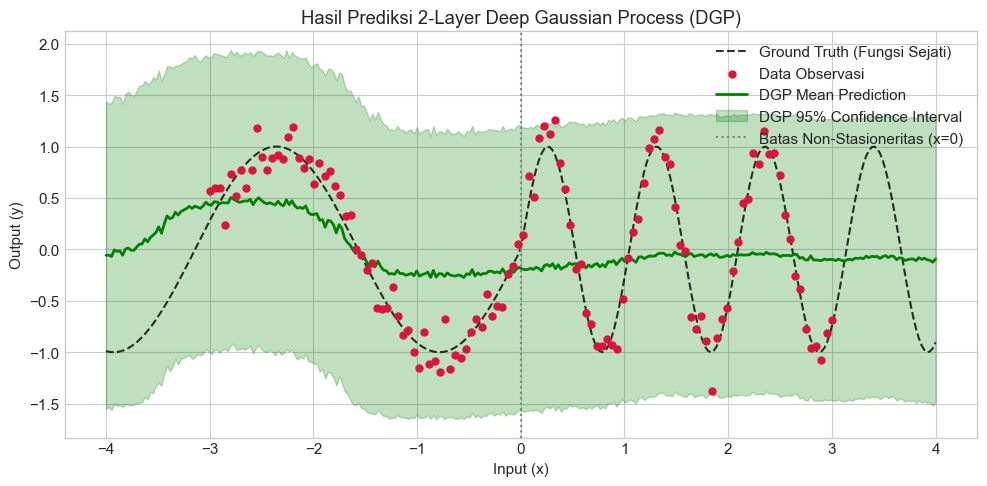

In [ ]:
# Inference / Prediksi pada Test Grid X_test
num_test_samples = 100

with torch.no_grad():
    # Sampling 100 jalur fungsi Monte Carlo dari Deep GP
    f_samples_test, latents_test = dgp_model.forward(X_test, num_samples=num_test_samples, return_latents=True)
    # f_samples_test: (100, 300, 1)
    
    # Hitung Rata-rata (Mean) dan Standar Deviasi (Uncertainty) Prediksi
    dgp_mean = f_samples_test.mean(dim=0).squeeze().numpy()
    dgp_std_f = f_samples_test.std(dim=0).squeeze().numpy()
    # Total std termasuk noise observasi
    dgp_std_total = np.sqrt(dgp_std_f**2 + dgp_model.noise.item())

# Visualisasi Prediksi 2-Layer Deep GP
plt.figure(figsize=(10, 5))
plt.plot(X_test.numpy(), Y_test_true.numpy(), 'k--', label='Ground Truth (Fungsi Sejati)', alpha=0.8)
plt.scatter(X_train.numpy(), Y_train.numpy(), c='crimson', s=25, label='Data Observasi', zorder=4)

plt.plot(X_test.numpy(), dgp_mean, 'g-', linewidth=2, label='DGP Mean Prediction')
plt.fill_between(X_test.squeeze().numpy(), dgp_mean - 2*dgp_std_total, dgp_mean + 2*dgp_std_total, color='green', alpha=0.25, label='DGP 95% Confidence Interval')

plt.axvline(0, color='gray', linestyle=':', label='Batas Non-Stasioneritas (x=0)')
plt.title("Hasil Prediksi 2-Layer Deep Gaussian Process (DGP)")
plt.xlabel("Input (x)")
plt.ylabel("Output (y)")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Mengapa Deep GP Berhasil? Visualisasi *Input Space Warping* (Layer Tersembunyi)

Keunggulan utama Deep GP terletak pada kemampuan **Layer 1** untuk mempelajari fungsi pemetaan laten $h_1 = f^{(1)}(x)$:
- Pada area di mana fungsi target berubah sangat cepat ($x \ge 0$), Layer 1 **merekangkan** (*stretches*) nilai $h_1$.
- Pada area di mana fungsi target berubah lambat ($x < 0$), Layer 1 **mendorong/menekan** (*compresses*) nilai $h_1$.

Dengan demikian, ketika $h_1$ masuk ke **Layer 2**, fungsi tampak **stasioner bagi Kernel Layer 2**!

Mari kita visualisasikan representasi laten $h_1$ terhadap $x$.

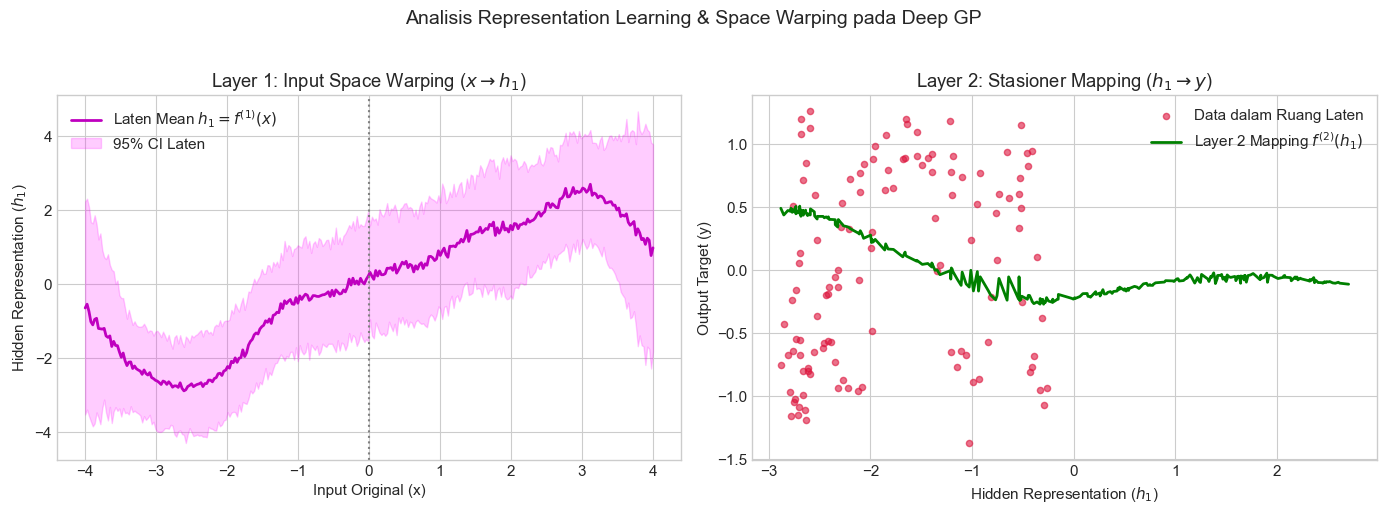

In [ ]:
# Visualisasi Input Space Warping (x -> h_1)
with torch.no_grad():
    # Latent output Layer 1: latents_test[1] berukuran (S, N, 1)
    H1_samples = latents_test[1].squeeze(-1).numpy() # (S, N)
    H1_mean = H1_samples.mean(axis=0)
    H1_std = H1_samples.std(axis=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Warping Function x -> h_1
ax1.plot(X_test.numpy(), H1_mean, 'm-', linewidth=2, label=r'Laten Mean $h_1 = f^{(1)}(x)$')
ax1.fill_between(X_test.squeeze().numpy(), H1_mean - 2*H1_std, H1_mean + 2*H1_std, color='magenta', alpha=0.2, label='95% CI Laten')
ax1.axvline(0, color='gray', linestyle=':')
ax1.set_title(r"Layer 1: Input Space Warping ($x \rightarrow h_1$)")
ax1.set_xlabel("Input Original (x)")
ax1.set_ylabel(r"Hidden Representation ($h_1$)")
ax1.legend()
ax1.grid(True)

# Plot 2: Latent h_1 vs Output y
ax2.scatter(H1_mean[:len(X_train)], Y_train.numpy(), c='crimson', s=20, alpha=0.6, label='Data dalam Ruang Laten')
# Urutkan H1_mean untuk plotting curve
sort_idx = np.argsort(H1_mean)
ax2.plot(H1_mean[sort_idx], dgp_mean[sort_idx], 'g-', linewidth=2, label=r'Layer 2 Mapping $f^{(2)}(h_1)$')
ax2.set_title(r"Layer 2: Stasioner Mapping ($h_1 \rightarrow y$)")
ax2.set_xlabel(r"Hidden Representation ($h_1$)")
ax2.set_ylabel("Output Target (y)")
ax2.legend()
ax2.grid(True)

plt.suptitle("Analisis Representation Learning & Space Warping pada Deep GP", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7. Head-to-Head Comparison: Single SVGP vs Deep GP

Mari kita bandingkan secara berdampingan (*side-by-side*) performa **Single-Layer SVGP** dan **2-Layer Deep GP** pada dataset non-stasioner ini.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Subplot 1: Single SVGP
axes[0].plot(X_test.numpy(), Y_test_true.numpy(), 'k--', label='Ground Truth', alpha=0.7)
axes[0].scatter(X_train.numpy(), Y_train.numpy(), c='crimson', s=20, alpha=0.7, label='Data Observasi')
axes[0].plot(X_test.numpy(), mu_sgp, 'b-', label='Single SVGP Mean')
axes[0].fill_between(X_test.squeeze().numpy(), mu_sgp - 2*std_sgp, mu_sgp + 2*std_sgp, color='blue', alpha=0.2, label='95% CI')
axes[0].axvline(0, color='gray', linestyle=':')
axes[0].set_title("Single-Layer SVGP (Gagal Menangkap Perubahan Frekuensi)", fontsize=12)
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend(loc='upper left')

# Subplot 2: Deep GP
axes[1].plot(X_test.numpy(), Y_test_true.numpy(), 'k--', label='Ground Truth', alpha=0.7)
axes[1].scatter(X_train.numpy(), Y_train.numpy(), c='crimson', s=20, alpha=0.7, label='Data Observasi')
axes[1].plot(X_test.numpy(), dgp_mean, 'g-', label='2-Layer Deep GP Mean')
axes[1].fill_between(X_test.squeeze().numpy(), dgp_mean - 2*dgp_std_total, dgp_mean + 2*dgp_std_total, color='green', alpha=0.25, label='95% CI')
axes[1].axvline(0, color='gray', linestyle=':')
axes[1].set_title("2-Layer Deep GP (Sukses Beradaptasi via Space Warping)", fontsize=12)
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()

## 8. Ringkasan & Kesimpulan

### 💡 Data Analysis & Modeling Key Findings:
1. **Keterbatasan Single-Layer GP / SVGP**: GP standar maupun Single-Layer SVGP dengan kernel RBF stasioner terikat pada nilai *lengthscale* konstan tunggal. Pada data non-stasioner, model terpaksa mengambil kompromi yang menyebabkan *over-smoothing* di area frekuensi tinggi dan perkiraan ketidakpastian yang buruk.
2. **Kekuatan Deep GP (DGP)**: Dengan menumpuk beberapa layer SVGP secara hierarkis ($y = f^{(2)}(f^{(1)}(x))$), DGP mampu mempelajari **representasi laten non-linear (space warping)** pada layer pertama. Ini mengubah ruang input non-stasioner menjadi representasi laten yang mudah dipetakan oleh layer berikutnya.
3. **Sparse Variational Inference Stochastic (DSVI)**: Karena pengintegralan variabel laten di layer tersembunyi *intractable*, kita menggunakan *Inducing Points* ($M \ll N$) dan *Reparameterization Trick* untuk memperkirakan ikatan ELBO dan mengalirkan gradien Monte Carlo antar layer secara stabil.

---

### 🚀 Next Steps & Rekomendasi Eksperimen Lanjutan:
- **Pengaturan Arsitektur**: Cobalah menambah jumlah titik induksi ($M=32$) atau mencoba arsitektur lebih dalam (3-Layer DGP) untuk data multi-dimensi.
- **Multivariate Latent Space**: Pada masalah klasifikasi atau data berdimensi tinggi, dimensi laten $h_1$ bisa dibuat lebih besar dari 1 ($D_{latent} > 1$) untuk meningkatkan kapasitas representasi.

1. "Bukankah MLE bisa untuk mencari parameter distribusi seperti mean dan variance?"
Jawaban: Benar sekali! Di statistika dasar, jika Anda punya data $x_1, \dots, x_N \sim \mathcal{N}(\mu, \sigma^2)$, Anda bisa menggunakan MLE untuk mencari estimasi nilai $\hat{\mu}$ dan $\hat{\sigma}^2$.

Namun, letak perbedaannya pada Gaussian Process (GP):

- Di model biasa, $\mu$ dan $\sigma^2$ adalah angka tetap (fixed parameters).
- Di Gaussian Process, nilai fungsi $f(x)$ di setiap titik adalah variabel acak laten (latent random variable) tak berhingga.
- Kita bukan sekadar mencari 1 angka $\mu$ dan $\sigma^2$ untuk seluruh dataset, melainkan ingin mencari distribusi fungsi di setiap titik input $x$ yang mungkin.
- Oleh karena itu, kita harus menggunakan kerangka kerja Bayesian Inference (menghitung distribusi posterior $p(f \mid y)$).

2. "Apakah kita menggunakan ELBO karena integralnya susah?"
Jawaban: YA, 100% TEPAT.

Dalam matematika Bayesian, untuk mendapatkan probabilitas data observasi $p(y)$ (disebut Evidence atau Marginal Likelihood), kita harus mengintegralkan seluruh kemungkinan fungsi $f$: $$p(y \mid X) = \int p(y \mid f) p(f \mid X) \, df$$

Pada Deep GP (DGP), karena layernya bertingkat, rumusnya menjadi integral berantai berlapis-lapis: $$p(y \mid X) = \int \dots \int p(y \mid h^{(L-1)}) \dots p(h^{(1)} \mid X) \, dh^{(1)} \dots dh^{(L-1)}$$

Karena variabel laten $h$ masuk ke dalam eksponensial matriks Kernel RBF: $$k(h_i, h_j) = \exp\left(-\frac{|h_i - h_j|^2}{2\ell^2}\right)$$ Integral ini terbukti secara matematis tidak memiliki rumus tertutup (analytically intractable)—tidak ada rumus antiturunan kalkulus yang bisa menyelesaikannya.

Karena menghitung nilai aslinya $p(y \mid X)$ mustahil, kita menggunakan ketidaksamaan Jensen (Jensen's Inequality) untuk membuat batas bawah matematisnya yang disebut ELBO (Evidence Lower Bound), di mana: $$\log p(y \mid X) \ge \text{ELBO}$$ Lalu kita memaksimalkan ELBO tersebut.

3. "Apakah jika kita sangat jago dan bisa mengerjakan integralnya, MLE tetap bisa?"
Jawaban: YA, BISA! Dan metode itu sebenarnya memang ADA, namanya Type-II MLE (Maximum Marginal Likelihood).

Bahkan, Anda sudah menggunakannya tanpa sadar di Notebook 01 (Gaussian Process Standar 1-Layer)!

- Pada GP Standar 1-Layer (Notebook 01): Karena hanya 1 layer dan likelihood-nya Gaussian, integral perkalian dua distribusi Gaussian BISA diselesaikan secara analitik: $$\underbrace{p(y \mid X, \theta)}_{\text{Marginal Likelihood}} = \int \underbrace{\mathcal{N}(y \mid f, \sigma_n^2 I)}_{\text{Likelihood } p(y \mid f)} \cdot \underbrace{\mathcal{N}(f \mid 0, K_{XX})}_{\text{Prior } p(f \mid X)} \, df = \mathcal{N}(y \mid 0, K{XX} + \sigma_n^2 I)$$ Di Notebook 01, hyperparameter kernel $\theta = (\ell, \sigma_f^2, \sigma_n^2)$ dioptimasi dengan memaksimalkan Marginal Likelihood di atas secara langsung. Itu adalah bentuk MLE (tepatnya Type-II MLE)!

- Mengapa tidak bisa di Deep GP? Bukan karena kita kurang jago aljabar, melainkan ketika fungsi Gauss dimasukkan ke dalam fungsi kernel non-linear lapis demi lapis, distribusinya bukan lagi Gaussian (non-Gaussianity), sehingga integral analitiknya memang tidak ada di alam semesta kalkulus.

**Mengapa Hasil Integralnya Bisa Langsung Jadi Begitu?**

Ingat hubungan dasar regresi Gaussian Process: $$y = f(x) + \epsilon$$

- $f(x)$ adalah sinyal fungsi yang berdistribusi Gauss: $f \sim \mathcal{N}(0, K_{XX})$

- $\epsilon$ adalah noise observasi yang berdistribusi Gauss: $\epsilon \sim \mathcal{N}(0, \sigma_n^2 I)$

Dalam teori probabilitas, jika dua variabel acak Gaussian independen ($f$ dan $\epsilon$) dijumlahkan ($y = f + \epsilon$), maka hasilnya pasti Gaussian baru, di mana:

- Mean baru: $\mathbb{E}[y] = \mathbb{E}[f] + \mathbb{E}[\epsilon] = 0 + 0 = 0$

- Kovariansi baru: $\text{Cov}(y) = \text{Cov}(f) + \text{Cov}(\epsilon) = K_{XX} + \sigma_n^2 I$

Proses pengintegralan $\int p(y \mid f) p(f) \, df$ di atas sebenarnya adalah operasi konvolusi dua kurva Gaussian, yang menghasilkan kurva Gaussian baru $\mathcal{N}(0, K_{XX} + \sigma_n^2 I)$.

**Mengapa Ada Integral dan Kenapa Begitu Susah pada Deep GP?**

Mari kita bandingkan alur integral pada 1 Layer vs 2 Layer (Deep GP):

🔹 Pada 1-Layer GP (Mudah):
$$x \longrightarrow f \longrightarrow y$$

Rumus: $p(y \mid x) = \int p(y \mid f) p(f \mid x) \, df$
Kenapa mudah? Karena $f$ masuk secara linier: $y = f + \epsilon$. Gaussian dikali Gaussian bisa diintegralkan dengan rumus aljabar tertutup (closed-form).

🔹 Pada 2-Layer Deep GP (Sangat Rumit & Mustahil Dihitung Eksak):
$$x \longrightarrow \underbrace{h}{\text{Layer 1}} \longrightarrow \underbrace{f}{\text{Layer 2}} \longrightarrow y$$ Di sini, output Layer 1 ($h$) menjadi input bagi kernel di Layer 2: $$p(y \mid x) = \int \int p(y \mid f) \cdot p(f \mid h) \cdot p(h \mid x) \, df \, dh$$

💥 Mengapa Integral terhadap $h$ Ini "Macet" Total?

Mari kita lihat bagaimana $h$ masuk ke dalam distribusi $p(f \mid h)$:

1. Matriks kovariansi kernel di Layer 2 bergantung pada $h$: $$K_{hh} = \exp\left( -\frac{(h_i - h_j)^2}{2\ell^2} \right)$$
2. Distribusi $p(f \mid h)$ mengandung invers matriks tersebut: $$p(f \mid h) \propto \exp\left( -\frac{1}{2} f^T (K_{hh})^{-1} f \right)$$
3. Ketika Anda mencoba mengintegralkan $h$ ($\int \dots dh$), Anda mencoba mengintegralkan variabel acak $h$ yang posisinya berada di dalam fungsi invers matriks $(K_{hh})^{-1}$, di mana elemen matriksnya sendiri adalah eksponensial dari $h$!
Dalam kalkulus analitik, integral bentuk seperti ini tidak memiliki rumus anti-turunan sama sekali (analytically intractable).

1. Definisi Distribusi Probabilitas Tiap Tahap

Misalkan kita memiliki $N$ data input $X = [x_1, x_2, \dots, x_N]^T \in \mathbb{R}^{N \times D}$ dan target observasi $y = [y_1, y_2, \dots, y_N]^T \in \mathbb{R}^N$.

A. Layer 1 (Prior Laten $h$):

Fungsi $f^{(1)}$ memetakan input $X$ ke variabel laten $h = [h_1, h_2, \dots, h_N]^T \in \mathbb{R}^N$: $$p(h \mid X) = \mathcal{N}(h \mid 0, K_{XX}^{(1)}) = \frac{1}{(2\pi)^{N/2} |K_{XX}^{(1)}|^{1/2}} \exp\left( -\frac{1}{2} h^T (K_{XX}^{(1)})^{-1} h \right)$$ di mana $[K_{XX}^{(1)}]_{ij} = k^{(1)}(x_i, x_j)$ adalah matriks kovariansi dari input data asli.

B. Layer 2 (Prior Fungsi Output $f$ Bersyarat $h$):

Fungsi $f^{(2)}$ menerima nilai laten $h$ sebagai inputnya untuk menghasilkan fungsi output $f \in \mathbb{R}^N$: $$p(f \mid h) = \mathcal{N}(f \mid 0, K_{hh}^{(2)}) = \frac{1}{(2\pi)^{N/2} |K_{hh}^{(2)}|^{1/2}} \exp\left( -\frac{1}{2} f^T (K_{hh}^{(2)})^{-1} f \right)$$ di mana setiap elemen matriks kovariansi $K_{hh}^{(2)}$ bergantung langsung pada nilai $h$: $$[K_{hh}^{(2)}]{ij} = \sigma{f2}^2 \exp\left( -\frac{(h_i - h_j)^2}{2\ell_2^2} \right)$$

C. Observational Likelihood ($y$ dari $f$):

Data target $y$ diasumsikan mengalami gangguan noise Gaussian $\epsilon \sim \mathcal{N}(0, \sigma_n^2)$: $$p(y \mid f) = \mathcal{N}(y \mid f, \sigma_n^2 I) = \frac{1}{(2\pi \sigma_n^2)^{N/2}} \exp\left( -\frac{1}{2\sigma_n^2} |y - f|^2 \right)$$

2. Bentuk Integral Penuh (Joint Marginal Likelihood)

Untuk menghitung probabilitas data observasi $p(y \mid X)$, kita harus mengintegralkan kedua variabel laten yang tidak terobservasi ($f$ dan $h$):

$$p(y \mid X) = \int_{\mathbb{R}^N} \int_{\mathbb{R}^N} p(y \mid f) \cdot p(f \mid h) \cdot p(h \mid X) \, df \, dh$$

Mari kita selesaikan tahap demi tahap:

🔹 Tahap 1: Mengintegralkan terhadap $f$ ($\int \dots df$)

Karena $p(y \mid f)$ dan $p(f \mid h)$ sama-sama Gaussian terhadap $f$, pengintegralan terhadap $f$ bisa diselesaikan secara analitik (konvolusi 2 Gaussian):

$$\int_{\mathbb{R}^N} p(y \mid f) p(f \mid h) \, df = \mathcal{N}(y \mid 0, K_{hh}^{(2)} + \sigma_n^2 I)$$ $$= \frac{1}{(2\pi)^{N/2} \left| K_{hh}^{(2)} + \sigma_n^2 I \right|^{1/2}} \exp\left( -\frac{1}{2} y^T \left( K_{hh}^{(2)} + \sigma_n^2 I \right)^{-1} y \right)$$

🔹 Tahap 2: Mengintegralkan terhadap $h$ ($\int \dots dh$) — BENTUK SPESIFIKNYA

Sekarang kita substitusikan hasil Tahap 1 ke dalam integral terhadap $h$:

$$p(y \mid X) = \int_{\mathbb{R}^N} \underbrace{\frac{1}{(2\pi)^{N/2} \left| K_{hh}^{(2)} + \sigma_n^2 I \right|^{1/2}} \exp\left( -\frac{1}{2} y^T \left( K_{hh}^{(2)} + \sigma_n^2 I \right)^{-1} y \right)}_{\text{Hasil Integrasi Layer 2 (Bergantung Non-Linear pada } h)} \cdot \underbrace{\frac{1}{(2\pi)^{N/2} |K_{XX}^{(1)}|^{1/2}} \exp\left( -\frac{1}{2} h^T (K_{XX}^{(1)})^{-1} h \right)}_{\text{Distribusi Prior Layer 1 } p(h \mid X)} \, dh$$

**3. Mengapa Bentuk Integral Tahap 2 Ini Intractable?**

 Perhatikan posisi variabel integrasi $h = [h_1, \dots, h_N]$ di dalam integral di atas:

 1. Terkunci di dalam Eksponensial Matriks Kernel:

   Setiap elemen matriks $K_{hh}^{(2)}$ adalah $[K_{hh}^{(2)}]{ij} = \sigma{f_2}^2 \exp\left( -\frac{(h_i - h_j)^2}{2\ell_2^2} \right)$.

 2. Terkunci di dalam Invers Matriks:

   $h$ berada di dalam operasi invers $\left( K_{hh}^{(2)} + \sigma_n^2 I \right)^{-1}$.

 3. Terkunci di dalam Determinan Matriks:

   $h$ berada di dalam determinan $\left| K_{hh}^{(2)} + \sigma_n^2 I \right|^{1/2}$.

> 🛑 **Kesimpulan Matematis:**
>
>Tidak ada rumus kalkulus analitik yang dapat mengintegralkan perkalian fungsi eksponensial di mana variabel integrasinya ($h$) terperangkap di dalam invers dan determinan matriks eksponensial non-linear.
>
>Inilah alasan matematis fundamental mengapa Deep Gaussian Process WAJIB menggunakan metode aproksimasi seperti Variational Inference (DSVI / ELBO).